# Budget Optimization Model Training

This notebook trains and compares two optimization techniques:
1. **Linear Programming (LP)** - Mathematical optimization using PuLP
2. **Genetic Algorithm (GA)** - Evolutionary algorithm for optimization

## Objectives:
- Optimize budget allocation across categories
- Maximize savings while meeting essential needs
- Compare optimization approaches
- Generate optimal budget recommendations

## ⚠️ Important: Execution Order

**Please run cells in order:**
1. **Cell 1** - Import libraries
2. **Cell 2** - Load data (creates `transactions` and `budgets`)
3. **Cell 3** - Prepare optimization data (creates `opt_data`)
4. **Cell 5** - Run Linear Programming (creates `lp_results`, `lp_allocation`)
5. **Cell 7** - Run Genetic Algorithm (creates `ga_results`)
6. **Cell 8** - Compare GA results (creates `ga_allocation`)
7. **Cell 10** - Compare both methods

**If you get `NameError`, check which cell you need to run first!**


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully")


Libraries imported successfully


In [45]:
# Load or generate data
import sys
import os
sys.path.append('../utils')

try:
    from data_generator import generate_transaction_data, generate_budget_data
except ImportError:
    print("⚠️ data_generator not found. Creating simple budget generator...")
    def generate_budget_data(transactions_df):
        """Generate budget data based on transaction patterns"""
        budgets = []
        for user_id in transactions_df['user_id'].unique():
            user_transactions = transactions_df[transactions_df['user_id'] == user_id]
            for category in user_transactions['category'].unique():
                category_transactions = user_transactions[user_transactions['category'] == category]
                if len(category_transactions) > 0:
                    monthly_avg = category_transactions['amount'].sum() / (len(category_transactions) / 30) if len(category_transactions) > 0 else 0
                    daily_allocation = monthly_avg / 30 if monthly_avg > 0 else 0
                    budgets.append({
                        'user_id': user_id,
                        'category': category,
                        'monthly_budget': round(monthly_avg * 1.1) if monthly_avg > 0 else 10000,
                        'daily_allocation': round(daily_allocation) if daily_allocation > 0 else 300,
                    })
        return pd.DataFrame(budgets)

# Load transaction data
if not os.path.exists('../data/transactions.csv'):
    print("⚠️ transactions.csv not found!")
    print("Please ensure transactions.csv exists in ../data/")
    raise FileNotFoundError("transactions.csv not found in ../data/")
else:
    print("Loading existing data...")
    transactions = pd.read_csv('../data/transactions.csv')
    transactions['datetime'] = pd.to_datetime(transactions['datetime'])
    
    # Load budgets if exists, otherwise generate from transactions
    if os.path.exists('../data/budgets.csv'):
        print("✅ Found budgets.csv, loading...")
        budgets = pd.read_csv('../data/budgets.csv')
        print(f"✅ Loaded {len(budgets)} budget entries from file")
    else:
        print("⚠️ Budgets file not found. Generating from transactions...")
        budgets = generate_budget_data(transactions)
        budgets.to_csv('../data/budgets.csv', index=False)
        print(f"✅ Generated {len(budgets)} budget entries and saved to ../data/budgets.csv")

print(f"\n✅ Loaded {len(transactions)} transactions")
print(f"✅ Loaded {len(budgets)} budget entries")
print("\n📊 Budget data preview:")
print(budgets.head())


Loading existing data...
✅ Found budgets.csv, loading...
✅ Loaded 22 budget entries from file

✅ Loaded 806 transactions
✅ Loaded 22 budget entries

📊 Budget data preview:
    user_id             category  monthly_budget  daily_allocation
0  user_001             Shopping            1085                33
1  user_001      Mortgage & Rent           38900              1179
2  user_001          Restaurants            1065                32
3  user_001  Credit Card Payment           14668               444
4  user_001        Movies & DVDs             407                12


Optimization Data:
                  category  priority  monthly_budget  monthly_spent  \
0           Alcohol & Bars       3.0           712.0      20.066873   
1           Auto Insurance       3.0          2475.0      50.248139   
2             Coffee Shops       3.0           123.0       4.300496   
3      Credit Card Payment       3.0         14668.0    2365.798511   
4   Electronics & Software       3.0          5932.0      26.761787   
5            Entertainment       3.0           317.0       0.358065   
6                Fast Food       3.0           682.0      12.306328   
7            Food & Dining       3.0          1283.0       2.893921   
8               Gas & Fuel       3.0          1088.0      63.840074   
9                Groceries       3.0           878.0     104.040074   
10                 Haircut       3.0           960.0      14.069479   
11        Home Improvement       3.0         17502.0     710.652730   
12                Internet       3.0          2469.0      

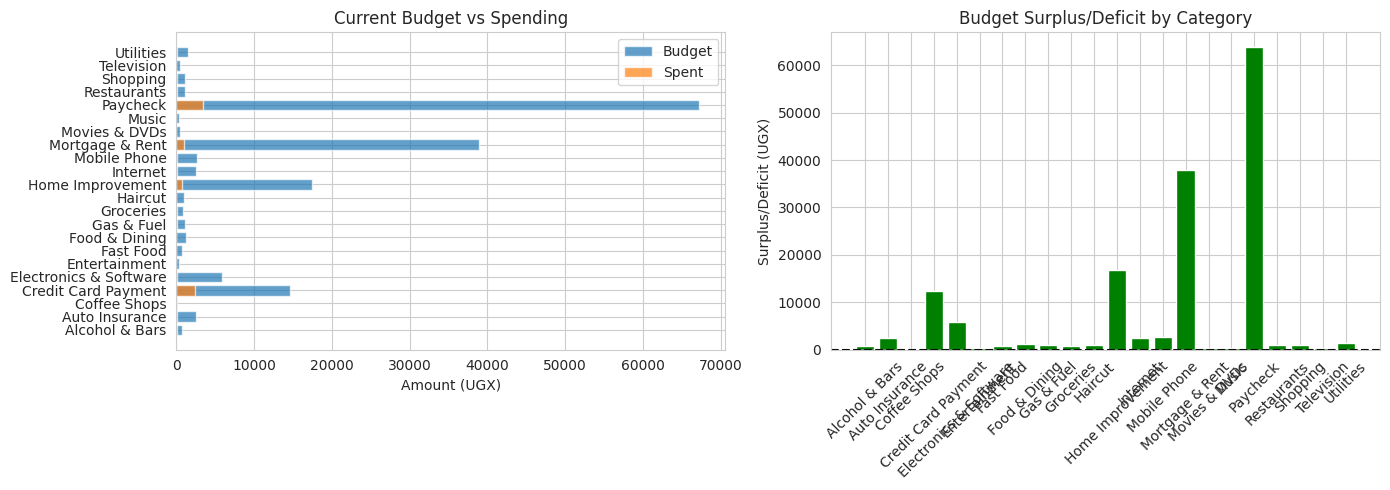

In [46]:
# Prepare optimization problem data
# For each user, calculate:
# 1. Historical spending by category
# 2. Budget constraints
# 3. Priority tiers
# 4. Optimization objectives

def prepare_optimization_data(transactions_df, budgets_df, user_id=None):
    """Prepare data for optimization"""
    if user_id:
        user_transactions = transactions_df[transactions_df['user_id'] == user_id].copy()
        user_budgets = budgets_df[budgets_df['user_id'] == user_id].copy()
    else:
        # Use aggregate data
        user_transactions = transactions_df.copy()
        user_budgets = budgets_df.groupby('category').agg({
            'monthly_budget': 'mean',
            'daily_allocation': 'mean'
        }).reset_index()
        user_budgets['user_id'] = 'aggregate'
    
    # Calculate historical spending
    category_spending = user_transactions.groupby('category')['amount'].agg(['sum', 'mean', 'std']).reset_index()
    category_spending.columns = ['category', 'total_spent', 'avg_transaction', 'std_transaction']
    
    # Merge with budgets
    optimization_data = user_budgets.merge(category_spending, on='category', how='left')
    optimization_data = optimization_data.fillna(0)
    
    # Define priority tiers (1 = Essential, 2 = Important, 3 = Optional)
    priority_map = {
        'Meals': 1,
        'Health & Wellness': 1,
        'Learning Materials': 2,
        'Transport': 2,
        'Utilities': 2,
        'Entertainment': 3
    }
    optimization_data['priority'] = optimization_data['category'].map(priority_map).fillna(3)
    
    # Calculate monthly spending
    days_in_period = 30
    optimization_data['monthly_spent'] = optimization_data['total_spent'] / (len(user_transactions) / days_in_period)
    optimization_data['monthly_spent'] = optimization_data['monthly_spent'].fillna(0)
    
    return optimization_data

# Prepare data for a sample user or aggregate
opt_data = prepare_optimization_data(transactions, budgets)
print("Optimization Data:")
print(opt_data[['category', 'priority', 'monthly_budget', 'monthly_spent', 'avg_transaction']])

# Visualize current allocation vs spending
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(opt_data['category'], opt_data['monthly_budget'], label='Budget', alpha=0.7)
axes[0].barh(opt_data['category'], opt_data['monthly_spent'], label='Spent', alpha=0.7)
axes[0].set_xlabel('Amount (UGX)')
axes[0].set_title('Current Budget vs Spending')
axes[0].legend()

axes[1].bar(opt_data['category'], opt_data['monthly_budget'] - opt_data['monthly_spent'], 
           color=['green' if x > 0 else 'red' for x in opt_data['monthly_budget'] - opt_data['monthly_spent']])
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_ylabel('Surplus/Deficit (UGX)')
axes[1].set_title('Budget Surplus/Deficit by Category')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


## Model 1: Linear Programming (LP)


In [47]:
# Check if opt_data exists
if 'opt_data' not in globals():
    raise NameError("❌ 'opt_data' is not defined. Please run Cell 3 first to prepare optimization data.")

from pulp import LpMaximize, LpProblem, LpVariable, lpSum, value

def optimize_budget_lp(opt_data, total_budget):
    """
    Optimize budget allocation using Linear Programming
    Objective: Maximize savings while ensuring essential needs are met
    """
    # Create problem
    prob = LpProblem("Budget_Optimization", LpMaximize)
    
    # Decision variables: allocation for each category
    categories = opt_data['category'].tolist()
    allocations = {cat: LpVariable(f"alloc_{cat}", lowBound=0, cat='Continuous') 
                   for cat in categories}
    
    # Objective: Maximize total savings (minimize total allocation)
    # But ensure we meet minimum requirements
    prob += lpSum([allocations[cat] for cat in categories])
    
    # Constraints
    # 1. Total budget constraint
    prob += lpSum([allocations[cat] for cat in categories]) <= total_budget
    
    # 2. Minimum requirements for essential categories (Priority 1)
    essential_cats = opt_data[opt_data['priority'] == 1]['category'].tolist()
    for cat in essential_cats:
        min_req = opt_data[opt_data['category'] == cat]['monthly_spent'].values[0] * 0.9  # 90% of historical
        prob += allocations[cat] >= min_req
    
    # 3. Maximum for optional categories (Priority 3)
    optional_cats = opt_data[opt_data['priority'] == 3]['category'].tolist()
    for cat in optional_cats:
        max_allowed = opt_data[opt_data['category'] == cat]['monthly_budget'].values[0] * 0.8  # 80% of current
        prob += allocations[cat] <= max_allowed
    
    # 4. Proportional constraints: Important categories should be between essential and optional
    important_cats = opt_data[opt_data['priority'] == 2]['category'].tolist()
    if len(essential_cats) > 0 and len(important_cats) > 0:
        avg_essential = lpSum([allocations[cat] for cat in essential_cats]) / len(essential_cats)
        for cat in important_cats:
            prob += allocations[cat] <= avg_essential * 1.5  # Important <= 1.5x average essential
    
    # Solve
    prob.solve()
    
    # Extract results
    results = {}
    total_allocated = 0
    for cat in categories:
        alloc_value = value(allocations[cat])
        results[cat] = alloc_value
        total_allocated += alloc_value
    
    results['total_allocated'] = total_allocated
    results['total_savings'] = total_budget - total_allocated
    results['savings_rate'] = (total_budget - total_allocated) / total_budget if total_budget > 0 else 0
    
    return results, prob.status

# Run LP optimization
total_budget = opt_data['monthly_budget'].sum()
print(f"Total available budget: {total_budget:.2f} UGX")

lp_results, lp_status = optimize_budget_lp(opt_data, total_budget)

print(f"\nLP Optimization Status: {lp_status}")
print(f"Total Allocated: {lp_results['total_allocated']:.2f} UGX")
print(f"Total Savings: {lp_results['total_savings']:.2f} UGX")
print(f"Savings Rate: {lp_results['savings_rate']:.2%}")

print("\nOptimal Allocation:")
lp_allocation = pd.DataFrame({
    'category': [k for k in lp_results.keys() if k not in ['total_allocated', 'total_savings', 'savings_rate']],
    'allocated': [lp_results[k] for k in lp_results.keys() if k not in ['total_allocated', 'total_savings', 'savings_rate']]
})
lp_allocation = lp_allocation.merge(opt_data[['category', 'monthly_budget', 'priority']], on='category')
lp_allocation['change'] = lp_allocation['allocated'] - lp_allocation['monthly_budget']
lp_allocation['change_pct'] = (lp_allocation['change'] / lp_allocation['monthly_budget'] * 100).fillna(0)
print(lp_allocation[['category', 'priority', 'monthly_budget', 'allocated', 'change', 'change_pct']].to_string(index=False))


Total available budget: 162681.00 UGX
Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/mukama/Desktop/mo/model/model/venv/lib/python3.12/site-packages/pulp/apis/../solverdir/cbc/linux/i64/cbc /tmp/6559b8a9e53d469a9fb2246470b1e7d7-pulp.mps -max -timeMode elapsed -branch -printingOptions all -solution /tmp/6559b8a9e53d469a9fb2246470b1e7d7-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 27 COLUMNS
At line 93 RHS
At line 116 BOUNDS
At line 117 ENDATA
Problem MODEL has 22 rows, 22 columns and 43 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 0 (-22) rows, 0 (-22) columns and 0 (-43) elements
Empty problem - 0 rows, 0 columns and 0 elements
Optimal - objective value 162681
After Postsolve, objective 162681, infeasibilities - dual 0 (0), primal 0 (0)
Optimal objective 162681 - 0 iterations time 0.002, Presolve 0.00
Option for printingOptions changed from norm

## Model 2: Genetic Algorithm (GA)


Running Genetic Algorithm...
gen	nevals	avg    	std   	min         	max    
0  	100   	-890648	653913	-2.41936e+06	55310.4
1  	64    	-1.13954e+06	2.38868e+06	-2.01261e+07	55310.4
2  	73    	-1.46062e+06	4.57208e+06	-3.36903e+07	55310.4
3  	61    	-432132     	681951     	-4.77226e+06	55310.4
4  	60    	-783232     	2.19483e+06	-1.81375e+07	55310.4
5  	58    	-369747     	1.00089e+06	-6.37087e+06	55310.4
6  	58    	-490849     	1.56558e+06	-1.1755e+07 	55310.4
7  	57    	-91472.1    	341382     	-1.80547e+06	86505.1
8  	62    	-285288     	1.0894e+06 	-6.86332e+06	88325.4
9  	62    	-252128     	1.41979e+06	-1.26426e+07	108222 
10 	54    	-41579.9    	409899     	-3.02072e+06	96463  
11 	48    	-53828.1    	564906     	-5.34734e+06	96463  
12 	49    	-159744     	980550     	-7.23327e+06	109209 
13 	63    	-88909.4    	648869     	-5.7677e+06 	109209 
14 	72    	-526040     	1.90603e+06	-1.22283e+07	109209 
15 	55    	-252939     	1.00248e+06	-7.23978e+06	115344 
16 	49    	-134681    

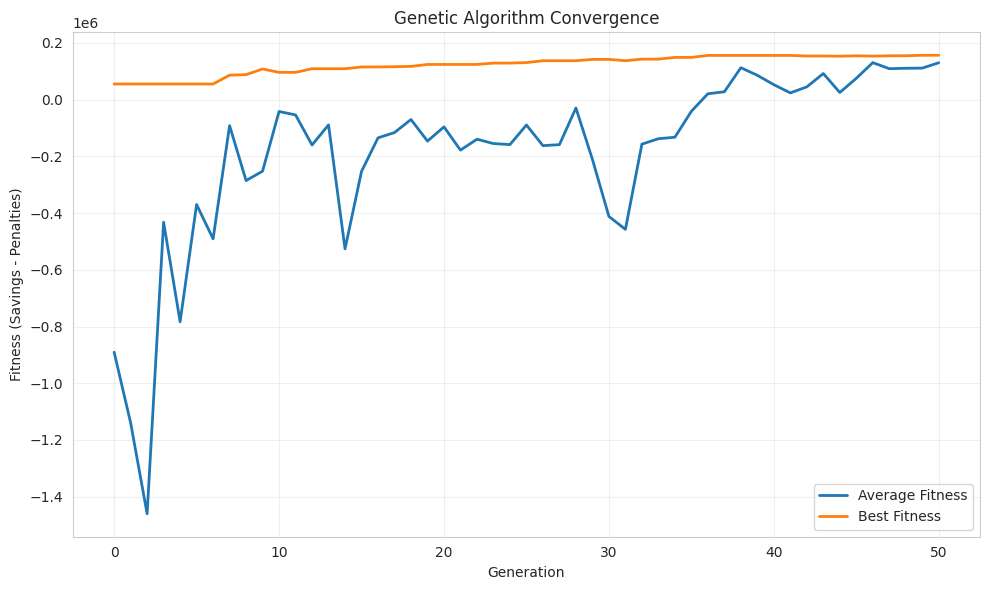

In [48]:
# Check if required variables exist
if 'opt_data' not in globals():
    raise NameError("❌ 'opt_data' is not defined. Please run Cell 3 first.")
if 'total_budget' not in globals():
    raise NameError("❌ 'total_budget' is not defined. Please run Cell 5 first.")

from deap import base, creator, tools, algorithms
import random

# Define fitness function
def evaluate_budget_allocation(individual, opt_data, total_budget):
    """
    Evaluate fitness of a budget allocation
    Higher fitness = better (more savings while meeting constraints)
    """
    categories = opt_data['category'].tolist()
    allocations = {cat: individual[i] for i, cat in enumerate(categories)}
    
    # Calculate total allocated
    total_allocated = sum(allocations.values())
    
    # Penalties for constraint violations
    penalty = 0
    
    # Constraint 0: NO NEGATIVE ALLOCATIONS (CRITICAL!)
    for cat in categories:
        if allocations[cat] < 0:
            penalty += abs(allocations[cat]) * 1000  # Heavy penalty for negative values
    
    # Constraint 1: Total budget
    if total_allocated > total_budget:
        penalty += (total_allocated - total_budget) * 10
    
    # Constraint 2: Minimum for essential categories
    essential_cats = opt_data[opt_data['priority'] == 1]['category'].tolist()
    for cat in essential_cats:
        min_req = opt_data[opt_data['category'] == cat]['monthly_spent'].values[0] * 0.9
        if allocations[cat] < min_req:
            penalty += (min_req - allocations[cat]) * 10
    
    # Constraint 3: Maximum for optional categories
    optional_cats = opt_data[opt_data['priority'] == 3]['category'].tolist()
    for cat in optional_cats:
        max_allowed = opt_data[opt_data['category'] == cat]['monthly_budget'].values[0] * 0.8
        if allocations[cat] > max_allowed:
            penalty += (allocations[cat] - max_allowed) * 10
    
    # Fitness = savings - penalties
    savings = total_budget - total_allocated
    fitness = savings - penalty
    
    return (fitness,)

# Setup GA
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

# Define gene (allocation for each category)
categories = opt_data['category'].tolist()
n_categories = len(categories)

# Gene bounds: 0 to 2x current budget
for cat in categories:
    max_val = opt_data[opt_data['category'] == cat]['monthly_budget'].values[0] * 2
    toolbox.register(f"attr_{cat}", random.uniform, 0, max_val)

# Create individual
toolbox.register("individual", tools.initCycle, creator.Individual,
                 [getattr(toolbox, f"attr_{cat}") for cat in categories], n=1)

# Create population
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Register evaluation, selection, crossover, mutation
toolbox.register("evaluate", evaluate_budget_allocation, opt_data=opt_data, total_budget=total_budget)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=total_budget * 0.1, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

# Ensure values stay positive after mutation
# Create a proper decorator function that handles keyword arguments
def checkBounds(mutate_func):
    """Decorator to ensure mutated values stay within bounds"""
    def wrapper(individual, *args, **kwargs):
        # First apply the mutation (pass through all arguments)
        # DEAP mutation functions return a tuple (individual,)
        result = mutate_func(individual, *args, **kwargs)
        # Extract individual from tuple if needed
        if isinstance(result, tuple):
            individual = result[0]
        # Then check and fix bounds
        for i, cat in enumerate(categories):
            max_val = opt_data[opt_data['category'] == cat]['monthly_budget'].values[0] * 2
            individual[i] = max(0, min(individual[i], max_val))
        # Return as tuple to match DEAP's expected format
        return (individual,)
    return wrapper

toolbox.decorate("mutate", checkBounds)

# Run GA
print("Running Genetic Algorithm...")
random.seed(42)
pop = toolbox.population(n=100)
hof = tools.HallOfFame(1)

stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)

pop, log = algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=50, 
                               stats=stats, halloffame=hof, verbose=True)

# Extract best solution
best_individual = hof[0]
ga_results = {}
for i, cat in enumerate(categories):
    ga_results[cat] = best_individual[i]

ga_results['total_allocated'] = sum(ga_results.values())
ga_results['total_savings'] = total_budget - ga_results['total_allocated']
ga_results['savings_rate'] = ga_results['total_savings'] / total_budget if total_budget > 0 else 0

print(f"\nGA Optimization Results:")
print(f"Total Allocated: {ga_results['total_allocated']:.2f} UGX")
print(f"Total Savings: {ga_results['total_savings']:.2f} UGX")
print(f"Savings Rate: {ga_results['savings_rate']:.2%}")

# Plot convergence
gen = log.select("gen")
fit_avg = log.select("avg")
fit_max = log.select("max")

plt.figure(figsize=(10, 6))
plt.plot(gen, fit_avg, label='Average Fitness', linewidth=2)
plt.plot(gen, fit_max, label='Best Fitness', linewidth=2)
plt.xlabel('Generation')
plt.ylabel('Fitness (Savings - Penalties)')
plt.title('Genetic Algorithm Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [49]:
# Check if required variables exist
if 'ga_results' not in globals():
    raise NameError("❌ 'ga_results' is not defined. Please run Cell 7 first to run the Genetic Algorithm.")
if 'opt_data' not in globals():
    raise NameError("❌ 'opt_data' is not defined. Please run Cell 3 first.")

# Compare GA results
ga_allocation = pd.DataFrame({
    'category': [k for k in ga_results.keys() if k not in ['total_allocated', 'total_savings', 'savings_rate']],
    'allocated': [ga_results[k] for k in ga_results.keys() if k not in ['total_allocated', 'total_savings', 'savings_rate']]
})
ga_allocation = ga_allocation.merge(opt_data[['category', 'monthly_budget', 'priority']], on='category')
ga_allocation['change'] = ga_allocation['allocated'] - ga_allocation['monthly_budget']
ga_allocation['change_pct'] = (ga_allocation['change'] / ga_allocation['monthly_budget'] * 100).fillna(0)

print("\nGA Optimal Allocation:")
print(ga_allocation[['category', 'priority', 'monthly_budget', 'allocated', 'change', 'change_pct']].to_string(index=False))



GA Optimal Allocation:
              category  priority  monthly_budget  allocated        change  change_pct
        Alcohol & Bars       3.0           712.0 316.353751   -395.646249  -55.568293
        Auto Insurance       3.0          2475.0  42.218580  -2432.781420  -98.294199
          Coffee Shops       3.0           123.0 127.685712      4.685712    3.809522
   Credit Card Payment       3.0         14668.0 418.776620 -14249.223380  -97.144964
Electronics & Software       3.0          5932.0   0.000000  -5932.000000 -100.000000
         Entertainment       3.0           317.0 213.009820   -103.990180  -32.804473
             Fast Food       3.0           682.0  44.496639   -637.503361  -93.475566
         Food & Dining       3.0          1283.0  62.098437  -1220.901563  -95.159904
            Gas & Fuel       3.0          1088.0  14.980105  -1073.019895  -98.623152
             Groceries       3.0           878.0 257.956335   -620.043665  -70.620007
               Haircut       3

## Model Comparison



Optimization Method Comparison:
            Method  Total Allocated  Total Savings  Savings Rate
Linear Programming    162681.000000       0.000000      0.000000
 Genetic Algorithm      5677.999823  157003.000177      0.965097


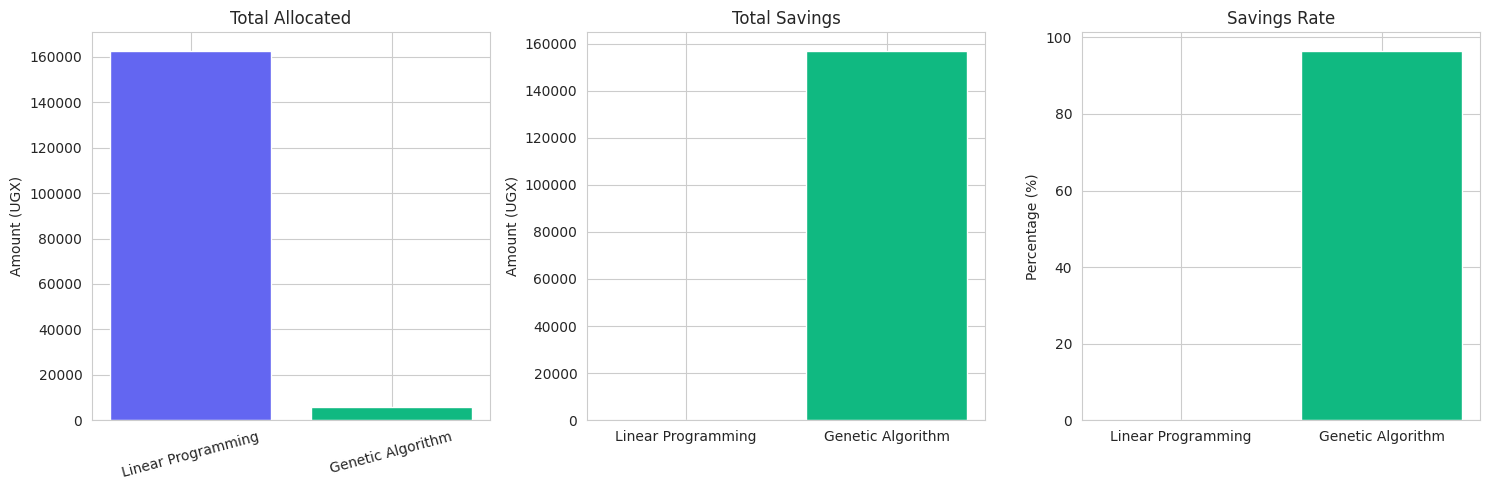


Allocation Comparison by Category:
              category  priority  monthly_budget  allocated_LP  allocated_GA
        Alcohol & Bars       3.0           712.0           0.0    316.353751
        Auto Insurance       3.0          2475.0           0.0     42.218580
          Coffee Shops       3.0           123.0           0.0    127.685712
   Credit Card Payment       3.0         14668.0           0.0    418.776620
Electronics & Software       3.0          5932.0           0.0      0.000000
         Entertainment       3.0           317.0           0.0    213.009820
             Fast Food       3.0           682.0           0.0     44.496639
         Food & Dining       3.0          1283.0           0.0     62.098437
            Gas & Fuel       3.0          1088.0           0.0     14.980105
             Groceries       3.0           878.0           0.0    257.956335
               Haircut       3.0           960.0           0.0    745.853611
      Home Improvement       3.0        

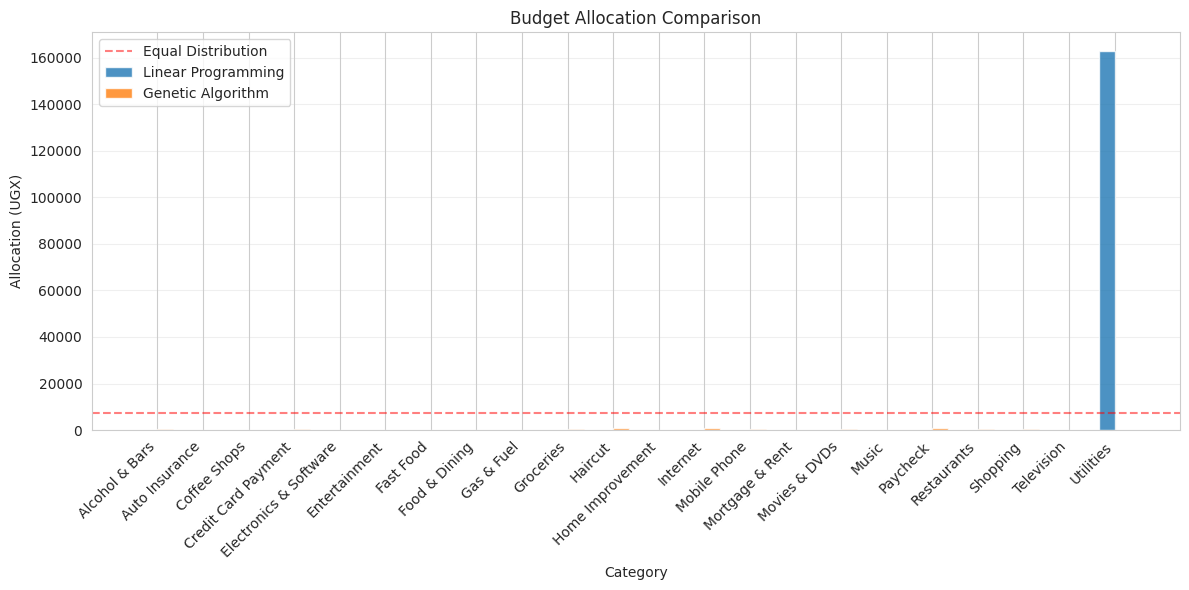


Best Method (based on savings): Genetic Algorithm


In [50]:
# Check if required variables exist
if 'lp_results' not in globals():
    raise NameError("❌ 'lp_results' is not defined. Please run Cell 5 first to run Linear Programming optimization.")
if 'ga_results' not in globals():
    raise NameError("❌ 'ga_results' is not defined. Please run Cell 7 first to run the Genetic Algorithm.")
if 'lp_allocation' not in globals():
    raise NameError("❌ 'lp_allocation' is not defined. Please run Cell 5 completely.")
if 'ga_allocation' not in globals():
    raise NameError("❌ 'ga_allocation' is not defined. Please run Cell 8 first.")

# Compare both methods
comparison = pd.DataFrame({
    'Method': ['Linear Programming', 'Genetic Algorithm'],
    'Total Allocated': [lp_results['total_allocated'], ga_results['total_allocated']],
    'Total Savings': [lp_results['total_savings'], ga_results['total_savings']],
    'Savings Rate': [lp_results['savings_rate'], ga_results['savings_rate']]
})

print("\nOptimization Method Comparison:")
print(comparison.to_string(index=False))

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Total allocated
axes[0].bar(comparison['Method'], comparison['Total Allocated'], color=['#6366f1', '#10b981'])
axes[0].set_ylabel('Amount (UGX)')
axes[0].set_title('Total Allocated')
axes[0].tick_params(axis='x', rotation=15)

# Total savings
axes[1].bar(comparison['Method'], comparison['Total Savings'], color=['#6366f1', '#10b981'])
axes[1].set_ylabel('Amount (UGX)')
axes[1].set_title('Total Savings')

# Savings rate
axes[2].bar(comparison['Method'], comparison['Savings Rate'] * 100, color=['#6366f1', '#10b981'])
axes[2].set_ylabel('Percentage (%)')
axes[2].set_title('Savings Rate')

plt.tight_layout()
plt.show()

# Compare allocations side by side
comparison_alloc = lp_allocation[['category', 'allocated']].merge(
    ga_allocation[['category', 'allocated']], 
    on='category', 
    suffixes=('_LP', '_GA')
)
comparison_alloc = comparison_alloc.merge(opt_data[['category', 'monthly_budget', 'priority']], on='category')

print("\nAllocation Comparison by Category:")
print(comparison_alloc[['category', 'priority', 'monthly_budget', 'allocated_LP', 'allocated_GA']].to_string(index=False))

# Visualize allocation differences
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_alloc))
width = 0.35

ax.bar(x - width/2, comparison_alloc['allocated_LP'], width, label='Linear Programming', alpha=0.8)
ax.bar(x + width/2, comparison_alloc['allocated_GA'], width, label='Genetic Algorithm', alpha=0.8)
ax.axhline(total_budget / len(categories), color='red', linestyle='--', label='Equal Distribution', alpha=0.5)

ax.set_xlabel('Category')
ax.set_ylabel('Allocation (UGX)')
ax.set_title('Budget Allocation Comparison')
ax.set_xticks(x)
ax.set_xticklabels(comparison_alloc['category'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Determine best method
best_method = 'Linear Programming' if lp_results['total_savings'] > ga_results['total_savings'] else 'Genetic Algorithm'
print(f"\nBest Method (based on savings): {best_method}")


In [51]:
# Check if required variables exist
if 'ga_results' not in globals():
    raise NameError("❌ 'ga_results' is not defined. Please run Cell 7 first to run the Genetic Algorithm.")
if 'opt_data' not in globals():
    raise NameError("❌ 'opt_data' is not defined. Please run Cell 3 first.")

# Compare GA results
ga_allocation = pd.DataFrame({
    'category': [k for k in ga_results.keys() if k not in ['total_allocated', 'total_savings', 'savings_rate']],
    'allocated': [ga_results[k] for k in ga_results.keys() if k not in ['total_allocated', 'total_savings', 'savings_rate']]
})
ga_allocation = ga_allocation.merge(opt_data[['category', 'monthly_budget', 'priority']], on='category')
ga_allocation['change'] = ga_allocation['allocated'] - ga_allocation['monthly_budget']
ga_allocation['change_pct'] = (ga_allocation['change'] / ga_allocation['monthly_budget'] * 100).fillna(0)

print("\nGA Optimal Allocation:")
print(ga_allocation[['category', 'priority', 'monthly_budget', 'allocated', 'change', 'change_pct']].to_string(index=False))



GA Optimal Allocation:
              category  priority  monthly_budget  allocated        change  change_pct
        Alcohol & Bars       3.0           712.0 316.353751   -395.646249  -55.568293
        Auto Insurance       3.0          2475.0  42.218580  -2432.781420  -98.294199
          Coffee Shops       3.0           123.0 127.685712      4.685712    3.809522
   Credit Card Payment       3.0         14668.0 418.776620 -14249.223380  -97.144964
Electronics & Software       3.0          5932.0   0.000000  -5932.000000 -100.000000
         Entertainment       3.0           317.0 213.009820   -103.990180  -32.804473
             Fast Food       3.0           682.0  44.496639   -637.503361  -93.475566
         Food & Dining       3.0          1283.0  62.098437  -1220.901563  -95.159904
            Gas & Fuel       3.0          1088.0  14.980105  -1073.019895  -98.623152
             Groceries       3.0           878.0 257.956335   -620.043665  -70.620007
               Haircut       3

## Save Models


In [52]:
import joblib
import json

# Check if required variables exist
required_vars = ['opt_data', 'total_budget', 'lp_results', 'ga_results', 'lp_allocation', 'ga_allocation']
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise NameError(f"❌ Missing required variables: {missing_vars}. Please run all previous cells in order.")

# Get categories if not already defined
if 'categories' not in globals():
    categories = opt_data['category'].tolist()

# Determine best method if not already set
if 'best_method' not in globals():
    best_method = 'Linear Programming' if lp_results['total_savings'] > ga_results['total_savings'] else 'Genetic Algorithm'

# Create models directory
os.makedirs('../models', exist_ok=True)

# Save optimization parameters and results
optimization_params = {
    'categories': list(categories),  # categories is already a list
    'priorities': opt_data.set_index('category')['priority'].to_dict(),
    'total_budget': float(total_budget),
    'lp_results': {k: float(v) for k, v in lp_results.items()},
    'ga_results': {k: float(v) for k, v in ga_results.items()},
    'best_method': best_method,
    'trained_date': datetime.now().isoformat()
}

with open('../models/optimization_params.json', 'w') as f:
    json.dump(optimization_params, f, indent=2)

# Save allocation templates
lp_allocation.to_csv('../models/lp_optimal_allocation.csv', index=False)
ga_allocation.to_csv('../models/ga_optimal_allocation.csv', index=False)

print("Optimization parameters saved")
print("Optimal allocations saved")
print(f"\nTraining completed! Best method: {best_method}")


Optimization parameters saved
Optimal allocations saved

Training completed! Best method: Genetic Algorithm
